# Algorithm Used: K-Nearest Neighbors (KNN) and RandomForestClassification
# Accuracy Achieved: ~90% and 92%
# Tools & Technologies: Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn, Pickl

# 📌 Loan Approval Prediction System using Machine Learning
# Project Overview

This project aims to predict whether a loan application will be approved or rejected based on applicant information such as income, education, loan amount, credit history, and other financial factors. The project uses Machine Learning techniques to automate and improve the loan approval process.

# 📊 Importing Required Libraries


In this section, all the required Python libraries for data analysis, visualization, preprocessing, and machine learning are imported.

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(r"/content/loan_data.csv")
print(df.head())

# 🔍 Understanding the Dataset


This section explores the structure of the dataset, including the number of rows, columns, data types, and  statistical information.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
df["person_age"]=df["person_age"].astype("int")
df.info()


In [ ]:
cat_columns = [col for col in df.columns if df[col].dtype == "object"]
num_columns = [col for col in df.columns if df[col].dtype != "object"]
print(f"Categorical columns is : {cat_columns}")
print(f"Numerical columns is : {num_columns}")

Categorical columns is : ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numerical columns is : ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'loan_status']


In [ ]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


# 🧹 Data Cleaning


Data cleaning is performed to identify and handle missing values, remove inconsistencies, and prepare the dataset for machine learning.

In [ ]:
df.isnull().sum()


,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


# **📈 Exploratory Data Analysis (EDA)**

EDA is used to understand the distribution of features, identify trends, detect outliers, and gain insights into the dataset through visualizations.

# **📊 Feature Distribution Analysis**


Histograms plots are used to analyze the distribution of numerical variables and understand their behavior.

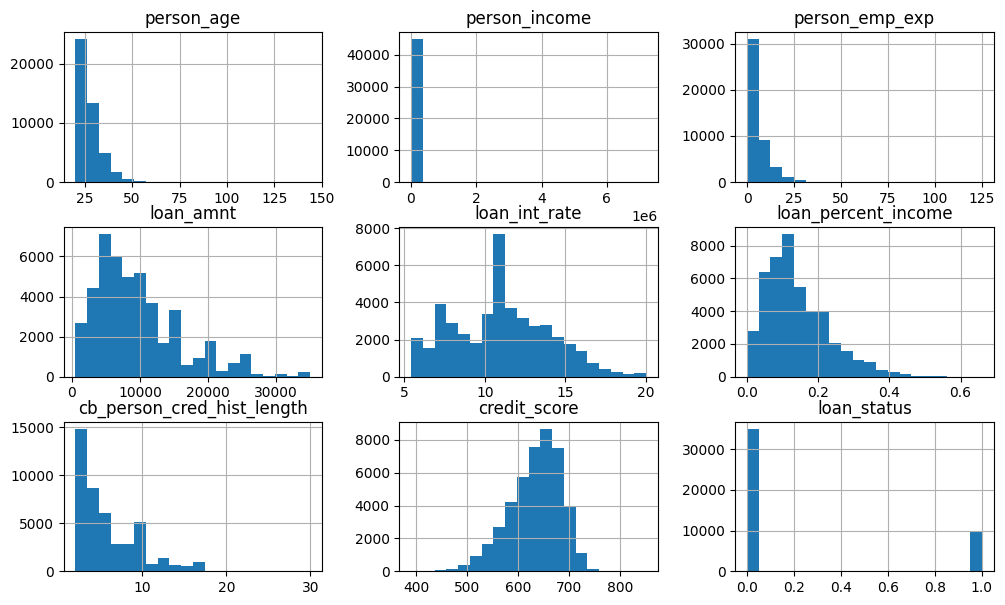

In [ ]:
df[num_columns].hist(figsize=(12,7),bins=20)
plt.show()

# EDA Summary

# Exploratory Data Analysis is that several numerical features such as income, employment experience, and loan amount are positively skewed and contain outliers. Credit scores follow a near-normal distribution, while loan status class imbalance. These insights helped guide preprocessing steps such as outlier treatment, scaling, and model selection.

# 📊 Age Distribution (person_age)

Insight:

Most applicants are between 20 and 40 years of age. The distribution is positively skewed, with very few applicants belonging to higher age groups.

# 💰 Income Distribution (person_income)

Insight:

Applicant income is highly right-skewed. Most applicants fall within lower to medium income ranges, while a small number of applicants have  high incomes.


# 👨‍💼 Employment Experience (person_emp_exp)

Insight:

The majority of applicants have relatively low employment experience. Only a few applicants possess very high work experience, indicating the presence of outliers.


# 🏦 Loan Amount (loan_amnt)

Insight:

Most loan applications are concentrated in the lower loan amount range. A smaller number of applicants request significantly higher loan amounts.


# 📈 Loan Interest Rate (loan_int_rate)

Insight:

Loan interest rates are primarily concentrated between 8% and 15%, with fewer applicants receiving very high interest rates.


# 📊 Loan Percent Income (loan_percent_income)

Insight:

Most applicants spend a relatively small proportion of their income on loan repayments. Higher loan-to-income ratios are less common.


# 💳 Credit History Length (cb_person_cred_hist_length)

Insight:

Most applicants have shorter credit histories, while only a small proportion have long credit histories. This indicates a concentration of relatively new borrowers.

# **📊 Feature Distribution Analysis**


Histograms and plots are used to analyze the distribution of  Categorical variables and understand their behavior.

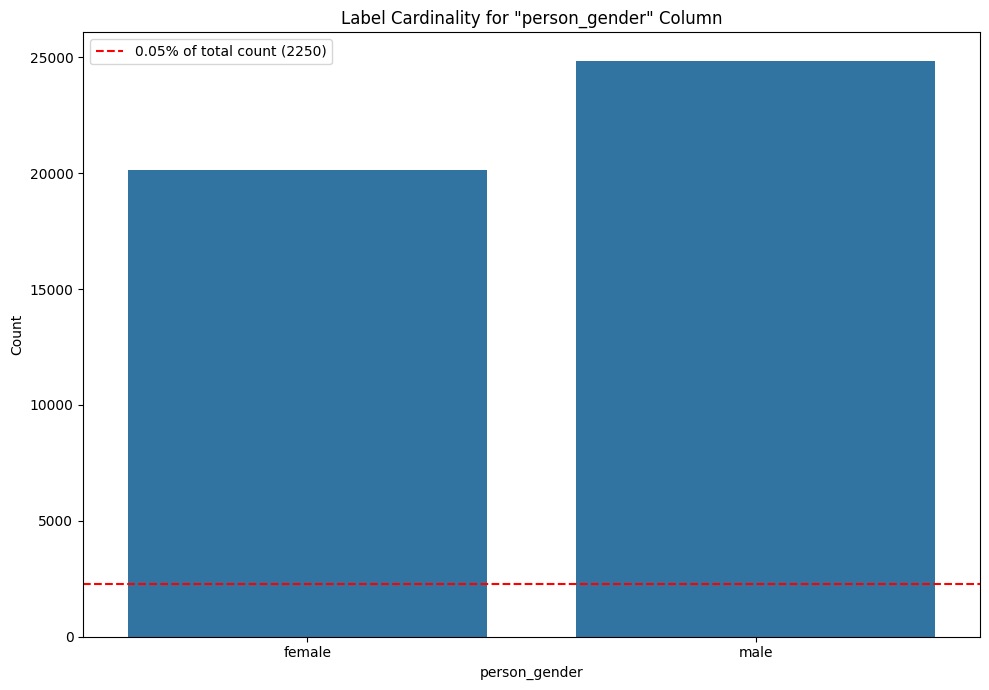

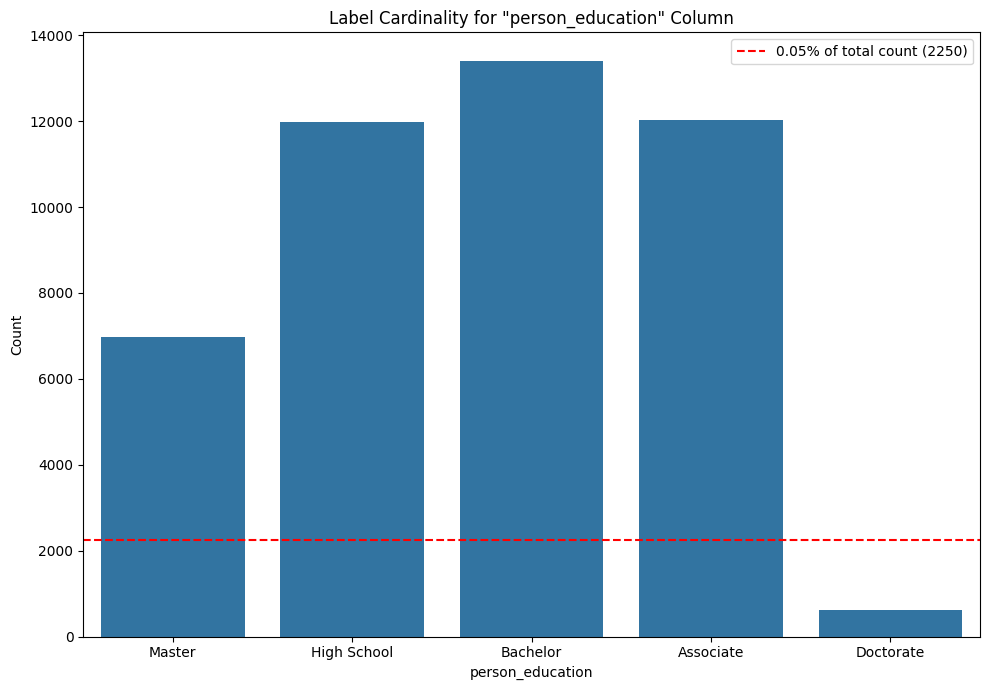

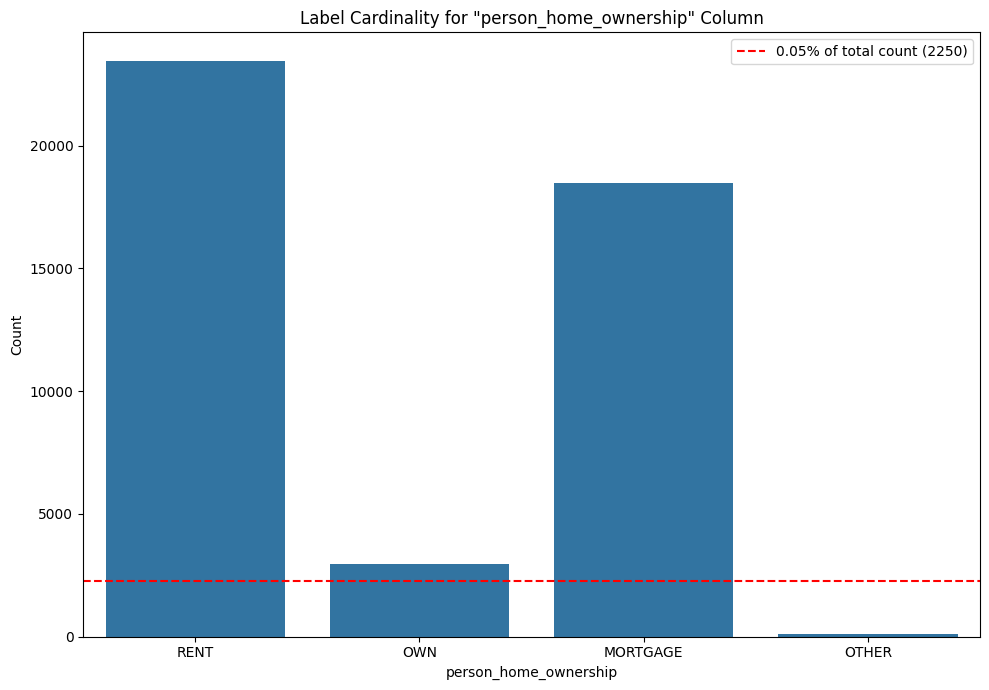

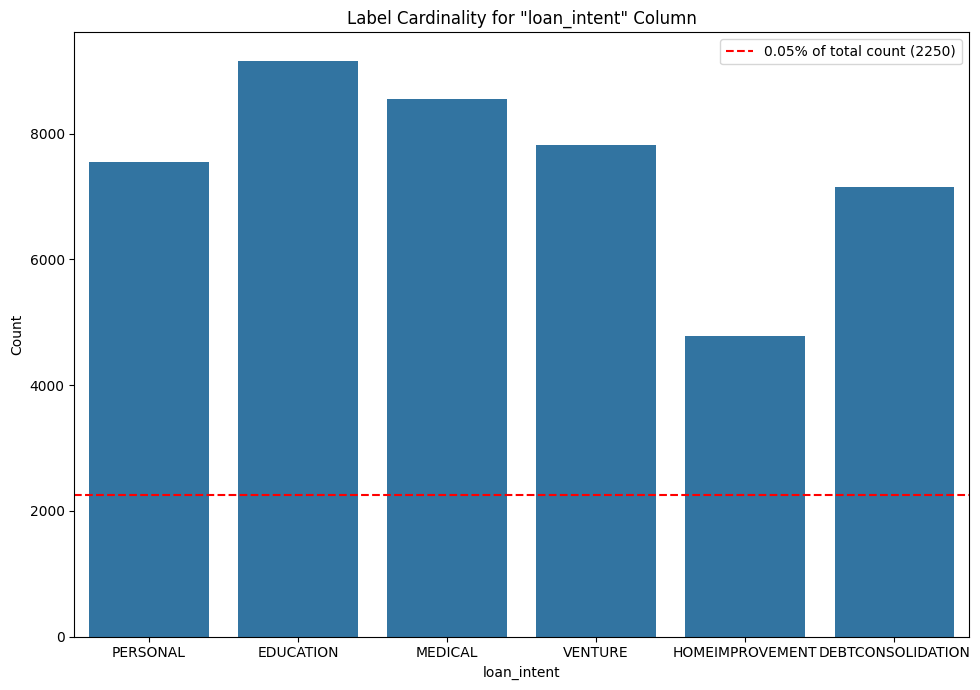

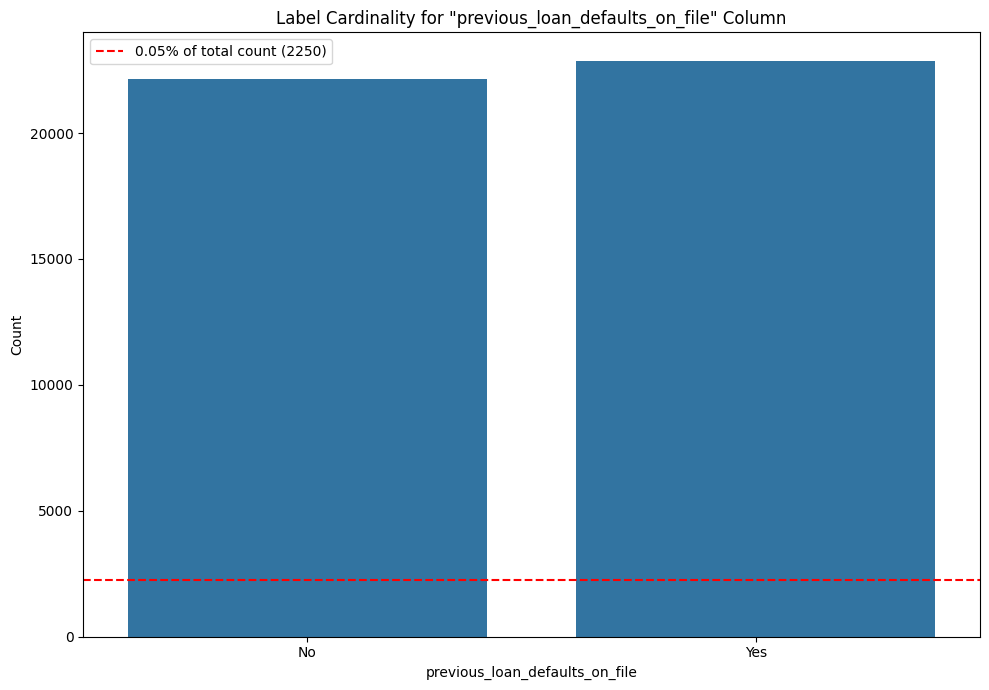

In [ ]:
def plot_categorical_column(dataframe, column):

    plt.figure(figsize=(10, 7))
    ax = sns.countplot(x=dataframe[column])
    total_count = len(dataframe[column])
    threshold = 0.05 * total_count
    category_counts = dataframe[column].value_counts(normalize=True) * 100
    ax.axhline(threshold, color='red', linestyle='--', label=f'0.05% of total count ({threshold:.0f})')

    plt.title(f'Label Cardinality for "{column}" Column')
    plt.ylabel('Count')
    plt.xlabel(column)
    plt.tight_layout()

    plt.legend()
    plt.show()

for col in cat_columns:
    plot_categorical_column(df, col)

In [ ]:
loan_status_count = df["loan_status"].value_counts()
loan_status_count.values


array([35000, 10000])

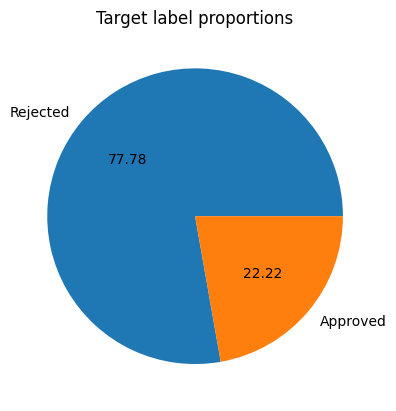

In [ ]:
plt.pie(x=loan_status_count.values,labels=["Rejected","Approved"],autopct='%.2f')
plt.title('Target label proportions')
plt.show()

# **🚨 Outlier Detection and Treatment**


Outliers are identified using statistical techniques such as the IQR method and are treated to improve model performance.

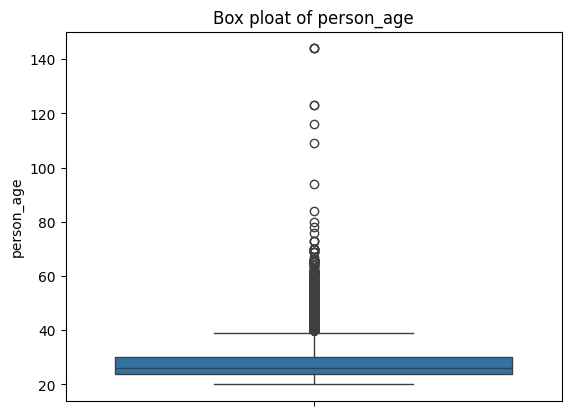

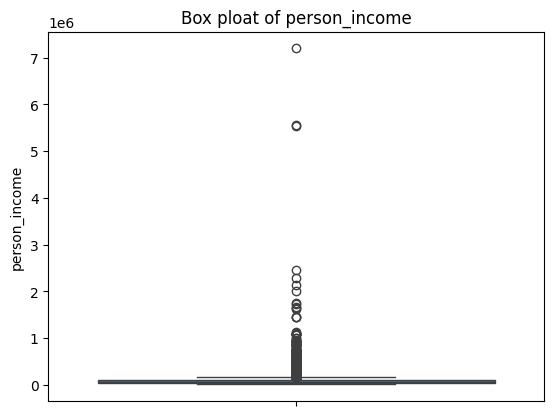

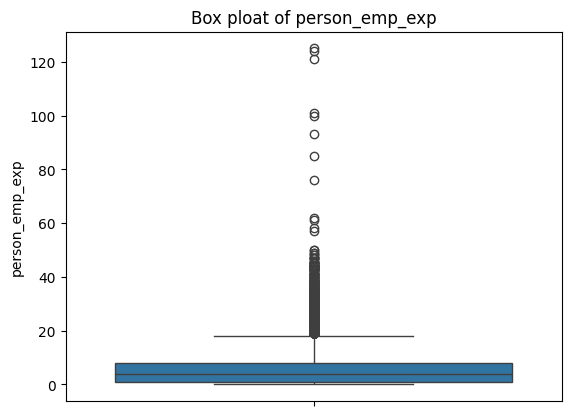

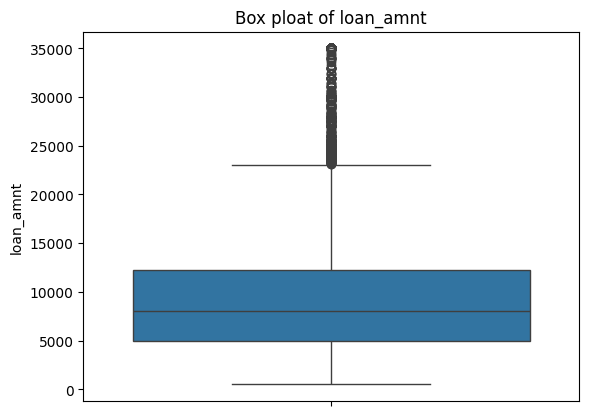

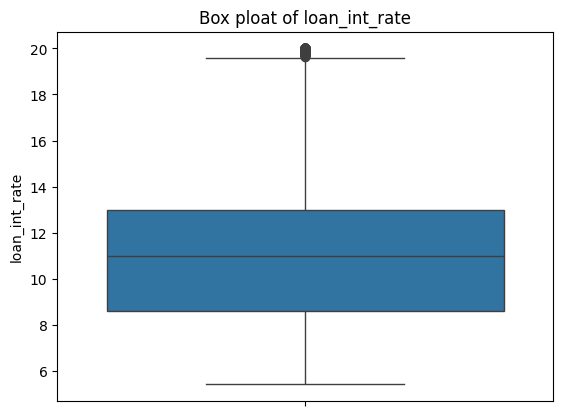

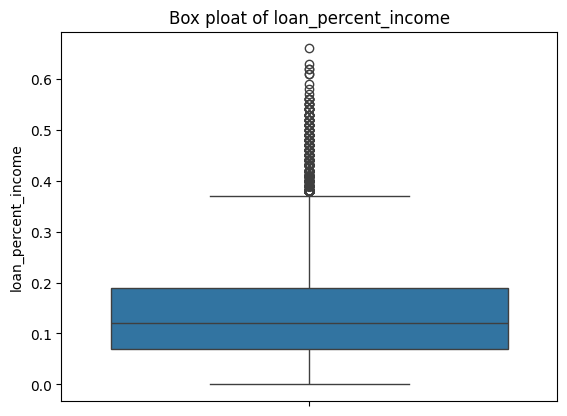

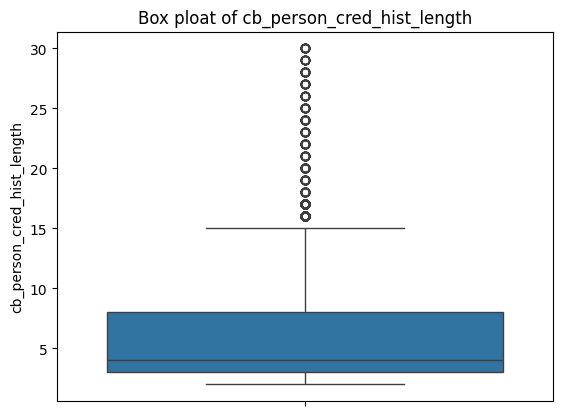

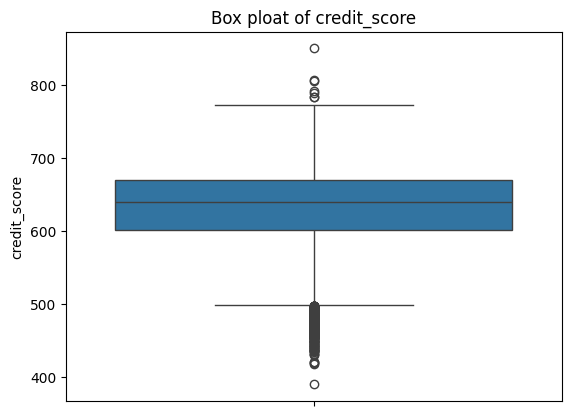

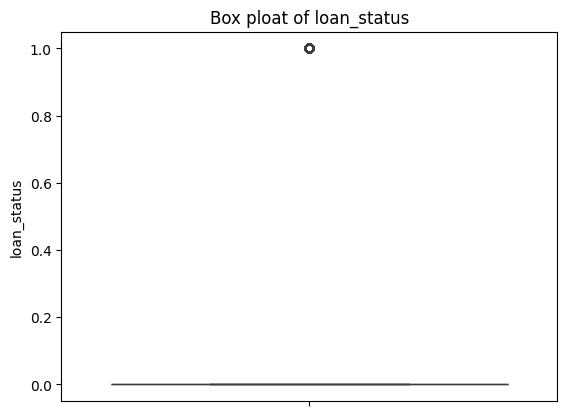

In [ ]:
for col in num_columns:
  sns.boxplot(df[col])
  plt.title(f"Box ploat of {col}")
  plt.show()

In [ ]:
skewed_cols = ['person_age', 'person_income', 'person_emp_exp',
               'loan_amnt', 'loan_percent_income',
               'cb_person_cred_hist_length', 'credit_score']

norm_cols= ['loan_int_rate']

# **⚖️ Feature Scaling**


Feature scaling is applied to normalize numerical variables and ensure that all features contribute equally during model training.

In [ ]:
mms = MinMaxScaler()
ss = StandardScaler()

df[skewed_cols] = ss.fit_transform(df[skewed_cols])
df[skewed_cols] = ss.transform(df[skewed_cols])

df[norm_cols] = mms.fit_transform(df[norm_cols])
df[norm_cols] = mms.transform(df[norm_cols])

# **🔄 Feature Encoding**


Categorical variables are converted into numerical format using encoding techniques so that machine learning algorithms can process them.

In [ ]:
gender_mapping = {'male': 0, 'female': 1}
home_ownership_mapping = {'RENT': 0, 'OWN': 1, 'MORTGAGE': 2, 'OTHER': 3}
loan_intent_mapping = {'PERSONAL': 0, 'EDUCATION': 1, 'MEDICAL': 2, 'VENTURE': 3, 'HOMEIMPROVEMENT': 4, 'DEBTCONSOLIDATION': 5}
previous_loan_defaults_mapping = {'No': 0, 'Yes': 1}


df['person_gender'] = df['person_gender'].map(gender_mapping)
df['person_home_ownership'] = df['person_home_ownership'].map(home_ownership_mapping)
df['loan_intent'] = df['loan_intent'].map(loan_intent_mapping)
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map(previous_loan_defaults_mapping)



In [ ]:
df['person_education'].replace({
    'High School': 0,
    'Associate': 1,
    'Bachelor': 2,
    'Master': 3,
    'Doctorate':4
}, inplace=True)

In [ ]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,-4.750624,1,3,-0.998726,-1.039442,0,-1.516930,0,-0.321878,44.451436,-1.702881,-12.571126,0,1
1,-4.777989,1,0,-0.998735,-1.039442,1,-1.517782,1,-0.344834,-9.454668,-1.769319,-12.593534,1,0
2,-4.668528,1,0,-0.998735,-0.957844,2,-1.517669,2,-0.336696,37.877521,-1.702881,-12.542035,0,1
3,-4.723258,1,2,-0.998725,-1.039442,0,-1.516930,2,-0.325594,37.877521,-1.769319,-12.526310,0,1
4,-4.695893,0,3,-0.998727,-1.012242,0,-1.516930,2,-0.330110,49.710568,-1.636444,-12.561298,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,-4.613797,0,1,-0.998730,-0.876246,0,-1.517431,2,-0.323571,20.785341,-1.702881,-12.538104,0,1
44996,-4.340143,1,1,-0.998727,-0.577053,0,-1.517582,4,-0.331051,-1.565970,-1.171381,-12.547539,0,1
44997,-4.449605,0,1,-0.998728,-0.849046,0,-1.517738,5,-0.350103,-13.399017,-1.237819,-12.529062,0,1
44998,-4.559066,0,2,-0.998732,-0.930644,0,-1.517506,1,-0.335002,27.359257,-1.503569,-12.554222,0,1


In [ ]:
from feature_engine.outliers import OutlierTrimmer

trimmer = OutlierTrimmer(capping_method='iqr', tail='right',
                        variables= ['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt',
       'loan_intent', 'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length', 'credit_score',
       'previous_loan_defaults_on_file'])

df2 = trimmer.fit_transform(df)

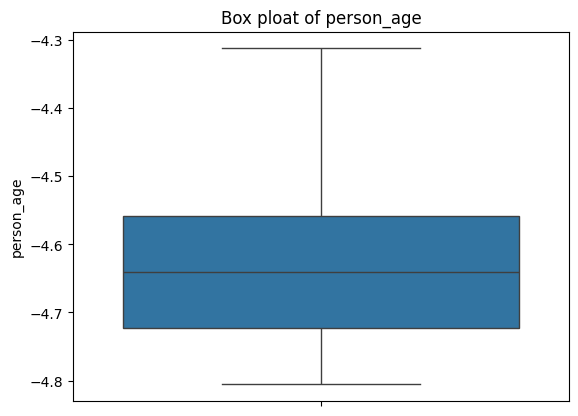

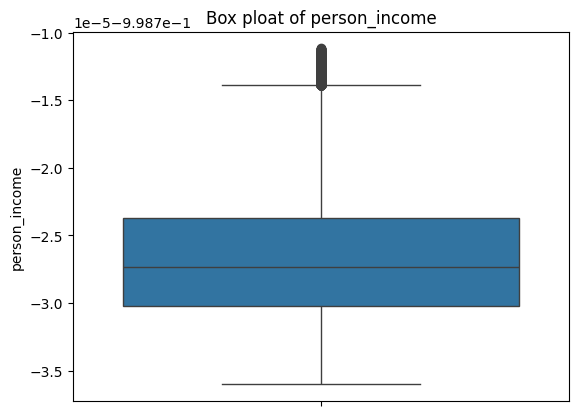

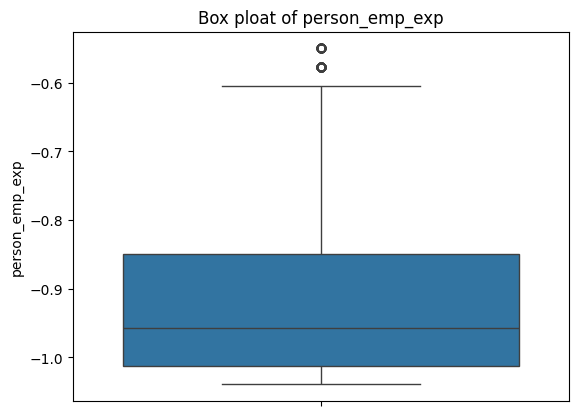

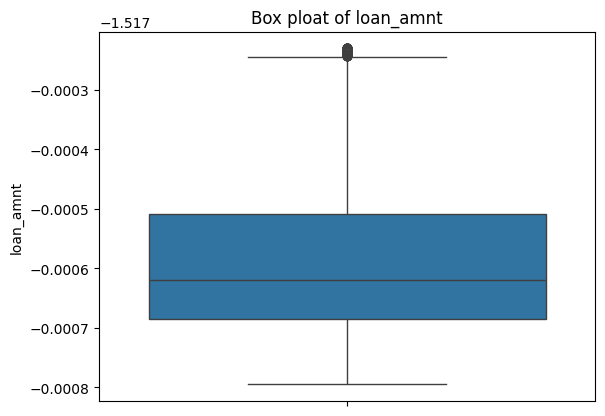

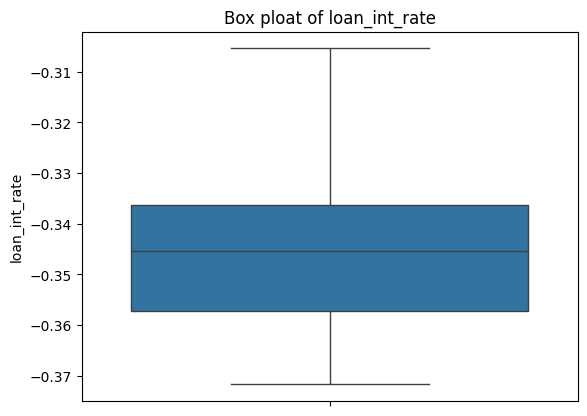

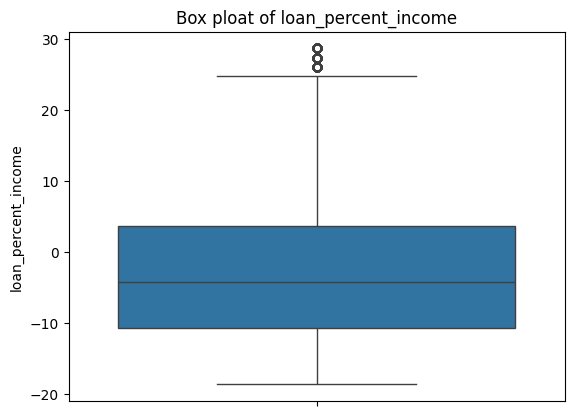

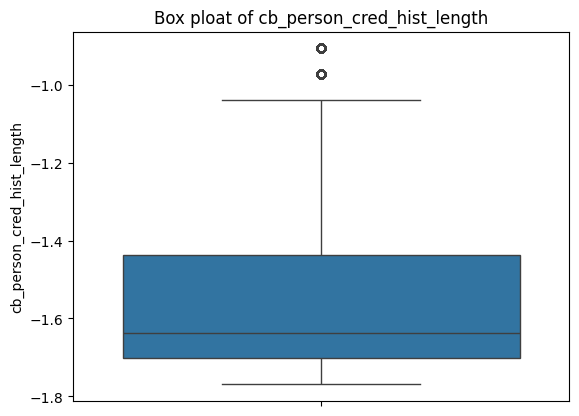

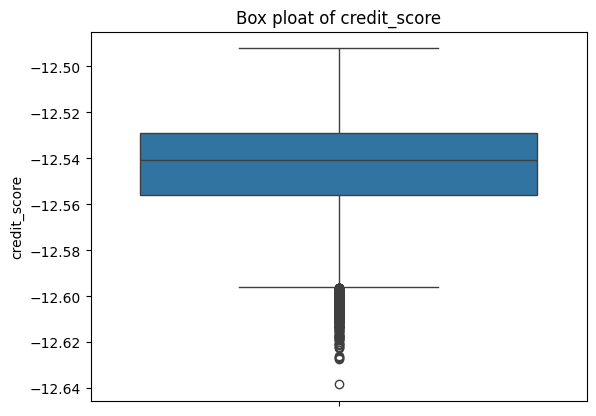

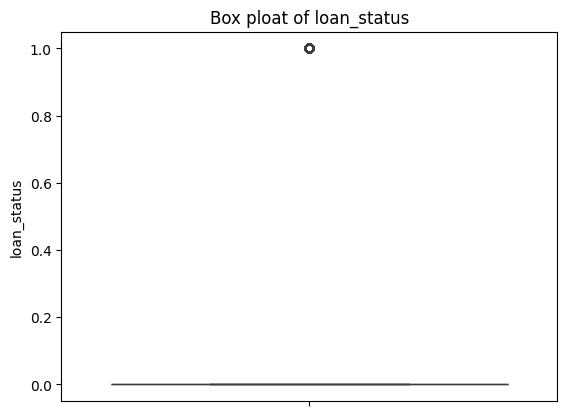

In [ ]:
for col in num_columns:
  sns.boxplot(df2[col])
  plt.title(f"Box ploat of {col}")
  plt.show()

# **🔗 Correlation Analysis**


Correlation analysis is performed to understand relationships between features and identify important variables affecting loan approval.

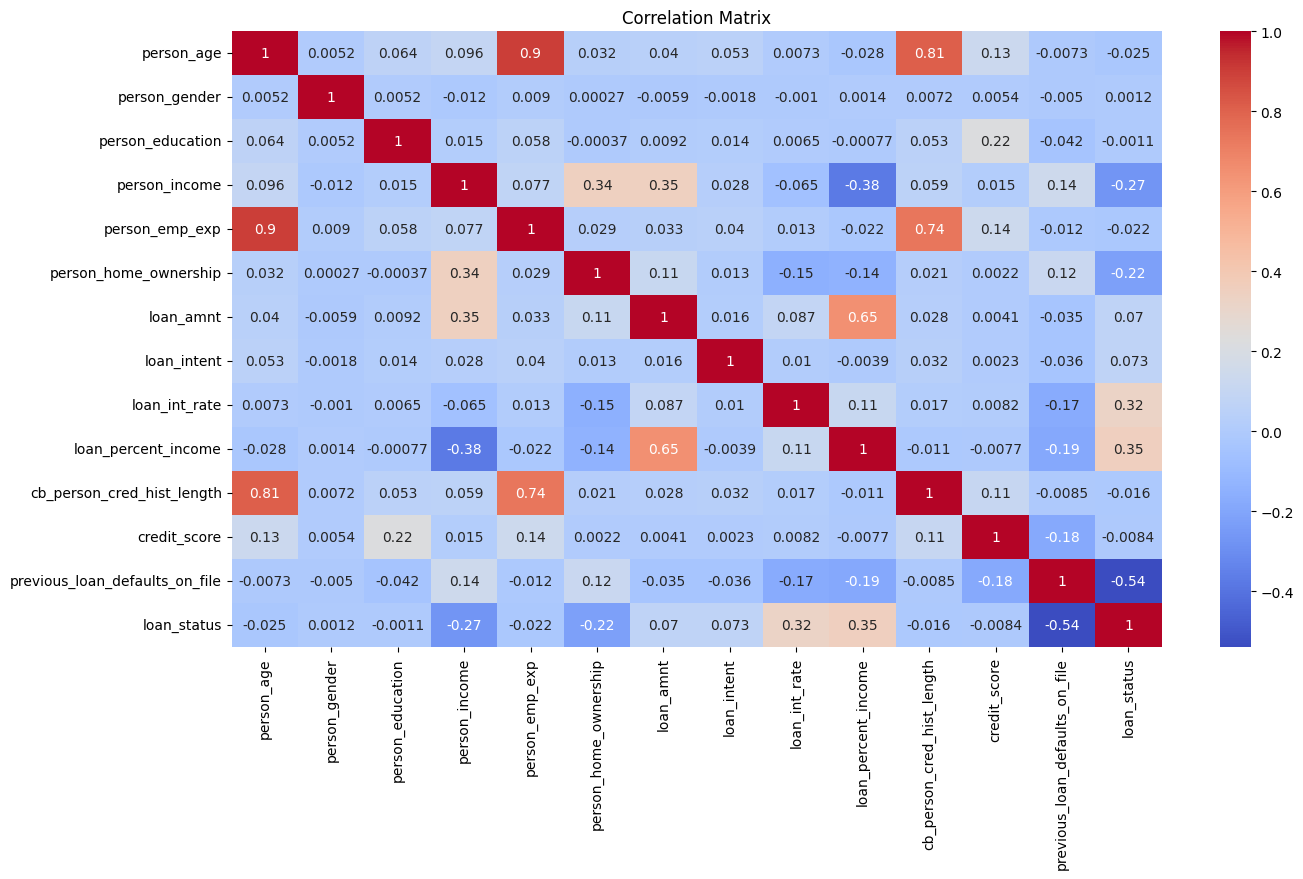

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df2.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [ ]:
threshold = 0.1

correlation_matrix = df2.corr()
high_corr_features = correlation_matrix.index[abs(correlation_matrix["loan_status"]) > threshold].tolist()
high_corr_features.remove("loan_status")
print(high_corr_features)

X_selected = df[high_corr_features]
Y = df["loan_status"]

['person_income', 'person_home_ownership', 'loan_int_rate', 'loan_percent_income', 'previous_loan_defaults_on_file']


# **✂️ Train-Test Split**


The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, Y, test_size=0.2, random_state=42)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((36000, 5), (36000,), (9000, 5), (9000,))

In [ ]:
df[high_corr_features]


,person_income,person_home_ownership,loan_int_rate,loan_percent_income,previous_loan_defaults_on_file
0,-0.998726,0,-0.321878,44.451436,0
1,-0.998735,1,-0.344834,-9.454668,1
2,-0.998735,2,-0.336696,37.877521,0
3,-0.998725,0,-0.325594,37.877521,0
4,-0.998727,0,-0.330110,49.710568,0
...,...,...,...,...,...
44995,-0.998730,0,-0.323571,20.785341,0
44996,-0.998727,0,-0.331051,-1.565970,0
44997,-0.998728,0,-0.350103,-13.399017,0
44998,-0.998732,0,-0.335002,27.359257,0


In [ ]:
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
model.score(X_train, y_train)


0.8711111111111111

In [ ]:
Y_pred = model.predict(X_test)
print(accuracy_score(y_test, Y_pred))

0.8658888888888889


In [ ]:
model2 = SVC()
model2.fit(X_train, y_train)

SVC()

In [ ]:
Y_pred2 = model2.predict(X_test)
print(accuracy_score(y_test, Y_pred2))

0.852


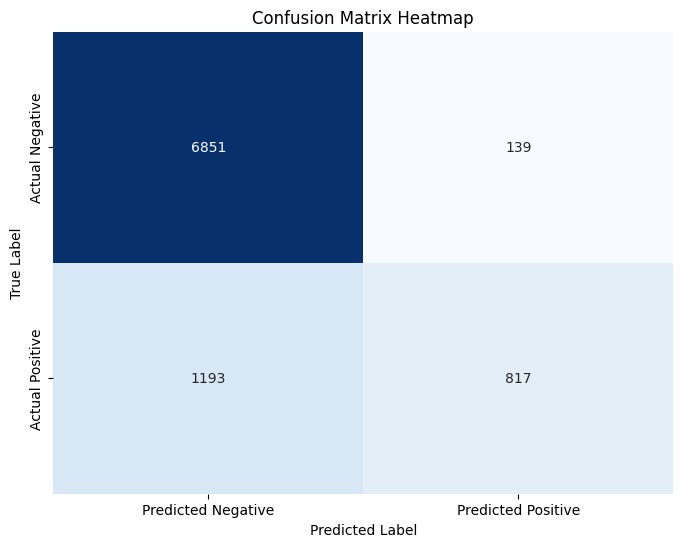

In [ ]:
conf_matrix2 =confusion_matrix(y_test, Y_pred2)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix2, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


# **🤖 Model Training – K-Nearest Neighbors (KNN)**


The KNN algorithm is trained using the processed dataset. The model predicts loan approval based on the nearest neighboring data points.

In [ ]:
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred_knn = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_knn)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 88.04%


# **Model Evaluation**


The trained model is evaluated using performance metrics such as accuracy, confusion matrix, and classification report.

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      6990
           1       0.75      0.70      0.72      2010

    accuracy                           0.88      9000
   macro avg       0.83      0.82      0.82      9000
weighted avg       0.88      0.88      0.88      9000



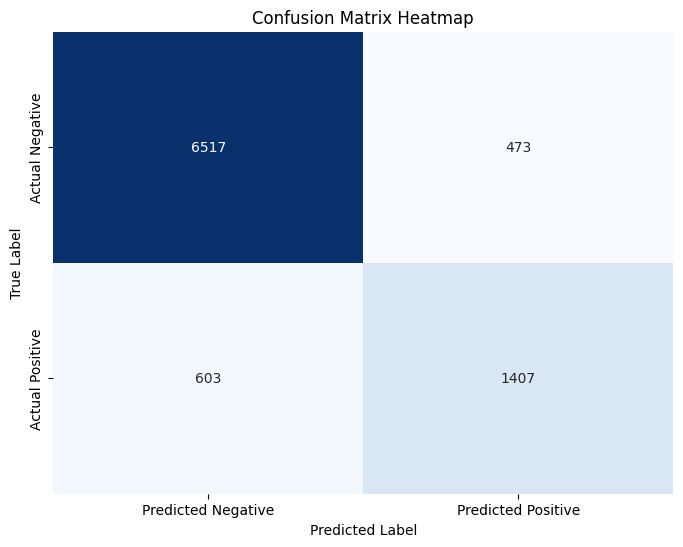

In [ ]:
conf_matrix3 =confusion_matrix(y_test, y_pred_knn)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix3, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

model_rf.fit(X_train,y_train)
y_pred_rf = model_rf.predict(X_test)
accuracy = accuracy_score(y_test,y_pred_rf)
print(f"Accuracy : {accuracy * 100 : .2f}%")

Accuracy :  91.77%


# **🎯 Conclusion**


**The Loan Approval Prediction System successfully predicts loan approval status based on applicant information. The model achieved approximately 92
% accuracy and can assist financial institutions in making faster and more consistent loan approval decisions.**